#**#Nombre: Santiago Mora Ortiz**

#**1. Abstract**

En muchas ocasiones, a los inversionistas les cuesta encontrar empresas que realmente den resultados. Esto se debe a diversas razones: informes financieros que tardan meses en publicarse, cifras incompletas o poco confiables, y la dificultad de comparar empresas de sectores y tamaños distintos. Esta incertidumbre lleva siempre a la misma pregunta difícil de responder al momento de sacar la billetera: ¿Será que me arriesgo o no?

Es así como este proyecto busca dar una respuesta basada en datos a esa pregunta. A partir de información financiera exacta de las 10.000 empresas más grandes de Colombia, se construye una investigación y dos modelos los cuales son evaluados para finalmente elegir el más capaz de predecir si una empresa es rentable o no, utilizando únicamente variables que normalmente están disponibles antes de conocer su resultado financiero final como su tamaño, estructura de deuda, liquidez, sector y ubicación geográfica.

El objetivo no es adivinar la cifra exacta de ganancia de una empresa, sino ofrecer una primera señal de riesgo, como una alerta temprana que ayude a decidir qué empresas merecen ser analizadas con más profundidad antes de invertir.

En esta investigación se entrenaron y compararon dos modelos de clasificación (Regresión logística y Random forest) evaluados principalmente mediante el F1-score de la clase "No Rentable", dado el fuerte desbalance del dataset (la mayoría de las empresas más grandes del país sí son rentables a comparación de las que no).

Se espera que el modelo, aunque no es perfecto, sea capaz de identificar patrones útiles que respalden decisiones de inversión más informadas, evidenciando además que la rentabilidad empresarial no depende de una sola señal financiera, sino de la combinación de diversos factores.


**Nota:** Al final de este proyecto, se encontrará un **glosario** con todas las variables financieras del dataset y las creadas a partir del mismo para ofrecer una mayor comprensión.

#**2. Problema y Contexto Comercial:**

**Problema**: Un inversionista, una entidad bancaria evaluando una línea de crédito, o incluso el Estado diseñando política económica para las empresas del país, con frecuencia deben tomar decisiones sobre una empresa sin tener acceso todavía a su informe de rentabilidad, ya sea porque la empresa es nueva, porque el reporte aún no se publica, o porque simplemente se quiere anticipar el riesgo antes de comprometer capital. Sin una herramienta que sistematice ese análisis, la decisión termina basándose en intuición, reputación de marca, o información incompleta y cuando la información si existe, el tiempo que conlleva revisar cada una de las compañías no es productivo ni rentable para nadie.

**Contexto de negocio:** Colombia tiene una estructura empresarial fuertemente concentrada en pocas regiones y sectores dominando buena parte de la economía a gran escala. Entender qué características de las empresas (tamaño, deuda, liquidez, sector, ubicación) se asocian con la rentabilidad no solo ayuda a tomar mejores decisiones de inversión individuales, sino que ofrece una mejor visión de qué partes de la estructura empresarial colombiana son más sólidas y cuáles enfrentan mayor riesgo financiero.

**Por qué es importante resolverlo:** anticipar el riesgo de que una empresa no sea rentable, sin depender de su informe financiero completo, permite actuar con tiempo, ya sea para decidir no invertir, para pedir garantías adicionales en un crédito, o para redirigir los recursos en las partes más vulnerables. Un modelo predictivo, aunque imperfecto, automatiza parte de este análisis y lo hace iterable a gran escala, algo que sería inviable de hacer manualmente para miles de empresas.

**Preguntas clave:**

- ¿Qué variables del balance general (tamaño, deuda, liquidez) se asocian con la rentabilidad de una empresa?

- ¿El sector económico o la región geográfica de una empresa influyen en su probabilidad de ser rentable?

- ¿Es posible predecir con un nivel de confianza razonable si una empresa es rentable, usando solo información disponible antes de conocer su resultado financiero final?

**Hipótesis:**

**H1: Sector y estructura financiera sobre rentabilidad**

La rentabilidad de una empresa no depende de un único factor o feature, sino de la combinación de variables estructurales como su sector económico, nivel de apalancamiento y liquidez. Se espera que, individualmente, ninguna de estas variables logre separar con claridad a las empresas rentables de las no rentables, lo cual justifica el uso de modelos de clasificación capaces de combinar múltiples señales moderadas en lugar de depender de una sola variable predictiva fuerte.

**H2: Desbalance estructural de clases**

Dado que el dataset corresponde a las empresas más grandes de Colombia, se espera que la gran mayoría sean rentables, generando un desbalance de clases significativo que dificultará que los modelos de clasificación logren un alto recall en la identificación de empresas no rentables, en comparación con su desempeño en la clase mayoritaria.

#**3. Metadatos y Fuentes**

**Fuente de datos:** EMIS (Emerging Markets Information Service), es una plataforma de información financiera empresarial. De aquí, extrajo el reporte de las 10.000 empresas más grandes de Colombia correspondientes al año fiscal 2025.

**Formato y tamaño:** archivo Excel (.xlsx), con 10.000 registros (uno por empresa) y 25 variables originales, reducidas a 9,471 registros luego del proceso de limpieza de datos.

**Variables principales:** identificación de la empresa (nombre, país); variables categóricas (sector según el 'CIIU' que es un código empresarial para identificar la actividad económica de una empresa en Colombia, región, ciudad); variables financieras de tamaño (ingresos operacionales, activos totales, pasivos totales, patrimonio, número de empleados); variables de liquidez (prueba ácida, rotación del activo corriente) y estructura de deuda (apalancamiento, calculado a partir de pasivos y patrimonio). A diferencia de fuentes públicas como Supersociedades, EMIS reporta las cifras financieras en pesos colombianos exactos, sin redondeos.

**Limitaciones:**

- Algunas variables de rentabilidad (ROA, ROE, margen operacional) se identificaron como derivadas directamente del resultado financiero de la empresa (ganancia neta), por lo que fueron excluidas para evitar revelarle a los modelos la respuesta exacta y mantener el objetivo de predecir la rentabilidad con información disponible de antemano.

- Diferentes variables presentaron valores atípicos extremos, posiblemente por la magnitud de las empresas que se encuentran en el extremo de ganancias (algunas son compañías demasiado grandes con valores exorbitantes mientras otras tienen muy pocas ganancias cercanas a 0 o incluso negativas).
Estos outliers fueron tratados mediante un recorte en percentiles que después iría solo del 1 y 99.

- La columna de sector (CIIU) incluía múltiples actividades económicas por empresa y demasiado específicas por lo que se utilizó únicamente la actividad principal para la clasificación sectorial.

- El dataset corresponde a un único año fiscal (2025), por lo que no permite evaluar los patrones encontrados a lo largo del tiempo.

- Existe un fuerte desbalance de clases en la variable objetivo (87.6% empresas rentables frente a 12.4% no rentables), lo cual condiciona tanto el diseño del modelado.

#**4 Creación del DataFrame**

A continuación encontramos la importación de las librerías a usar en esta investigación.

Asimismo encontramos:

- Verificación de columnas .shape ; .describe y .info

- Carga de los datos a un df

- Número de nulos

In [1]:
from google.colab import data_table
data_table.enable_dataframe_formatter()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://github.com/moraortizs17/proyecto_final_datascience_1/raw/refs/heads/main/Reporte%2010.000%20empresas%20m%C3%A1s%20grandes%20EMIS.xlsx"
df = pd.read_excel(url)

In [2]:
df.shape

(10000, 25)

In [3]:
df.dtypes

,0
Num,int64
País,object
Compañía,object
Sector (Local),object
Total Ingreso Operativo,int64
Estado/Provincia/Región,object
Ciudad,object
Activos Totales,int64
Pasivos Totales,int64
Total de patrimonio,int64


In [4]:
print(df.describe())

               Num  Total Ingreso Operativo  Activos Totales  Pasivos Totales  \
count  10000.00000             1.000000e+04     1.000000e+04     1.000000e+04   
mean    5000.50000             2.909496e+11     6.015079e+11     4.479274e+11   
std     2886.89568             1.760199e+12     7.542754e+12     6.899734e+12   
min        1.00000             3.226617e+10     1.000000e+05     0.000000e+00   
25%     2500.75000             4.579671e+10     2.749910e+10     1.193333e+10   
50%     5000.50000             7.345795e+10     6.150851e+10     2.788606e+10   
75%     7500.25000             1.610932e+11     1.647438e+11     7.621422e+10   
max    10000.00000             1.194054e+14     3.489367e+14     3.141938e+14   

       Total de patrimonio  Ganancia operativa (EBIT)  Margen Ebitda (%)  \
count         1.000000e+04               1.000000e+04       7.544000e+03   
mean          1.532525e+11               2.963997e+10       4.847584e+02   
std           3.083756e+12               3

In [5]:
df.info

<bound method DataFrame.info of         Num      País                                        Compañía  \
0         1  Colombia                                  Ecopetrol S.A.   
1         2  Colombia                   Colpensiones - Fondo de Vejez   
2         3  Colombia            Empresas Públicas de Medellin E.S.P.   
3         4  Colombia                        Organización Terpel S.A.   
4         5  Colombia          Grupo De Inversiones Suramericana S.A.   
...     ...       ...                                             ...   
9995   9996  Colombia           Parra Isaza Grupo Inversionista S.A.S   
9996   9997  Colombia  Empresa Forestal Y Agroambiental Efagram S.A.S   
9997   9998  Colombia                   Ingenieria y Contratos S.A.S.   
9998   9999  Colombia           Empresa de Agregados Calcareos S.A.S.   
9999  10000  Colombia                          Robenheim y Cia S.A.S.   

                                         Sector (Local)  \
0     Extracción De Petróleo Crudo (B0610); Extracci...   
1     Servicios De Seguros Sociales De Pensiones (K653)   
2     Transmisión De Energía Eléctrica (D3512); Capt...   
3     Comercio Al Por Mayor De Combustibles Sólidos,...   
4     Otras Actividades Relacionadas Con El Mercado ...   
...                                                 ...   
9995  Comercio Al Por Menor En Establecimientos No E...   
9996  Actividades De Apoyo A La Agricultura (A0161);...   
9997  Construcción De Carreteras Y Vías De Ferrocarr...   
9998         Fabricación De Cemento, Cal Y Yeso (C2394)   
9999  Comercio Al Por Menor De Combustible Para Auto...   

      Total Ingreso Operativo Estado/Provincia/Región         Ciudad  \
0             119405442562000              Bogotá D.C    Bogotá D.C.   
1              60578660832520              Bogotá D.C    Bogotá D.C.   
2              40911390000000               Antioquia       Medellín   
3              38203165546000              Bogotá D.C    Bogotá D.C.   
4              28706719000000               Antioquia       Medellín   
...                       ...                     ...            ...   
9995              32286626000               Santander  Floridablanca   
9996              32278702000                   Cauca        Popayán   
9997              32271004000               Antioquia       Medellín   
9998              32267054000               Antioquia   El Santuario   
9999              32266172000         Valle del Cauca           Cali   

      Activos Totales  Pasivos Totales  Total de patrimonio  ...  \
0     284136657544000  174890272167000      109246385377000  ...   
1      12726554207000    5658756969740        7067797237250  ...   
2      87230033000000   50540084000000       36689949000000  ...   
3       9603780651000    6191120617000        3412660034000  ...   
4      93145510000000   71577449000000       21568061000000  ...   
...               ...              ...                  ...  ...   
9995      27371726000      20566602000           6805124000  ...   
9996       5535040000       4092236000           1442804000  ...   
9997      40611755000      27651431000          12960324000  ...   
9998      15995381000       4736185000          11259196000  ...   
9999        936244000        437018000            499226000  ...   

     Prueba Ácida (x)  Rotación Del Activo Corriente (x)  \
0                1.30                               2.24   
1               12.03                               0.00   
2                1.28                               2.38   
3                0.98                               8.80   
4                 NaN                                NaN   
...               ...                                ...   
9995             0.15                               5.96   
9996             1.10                               7.17   
9997             2.23                               0.82   
9998             1.80                               3.63   
9999             1.56                   

In [6]:
df.isnull().sum()

,0
Num,0
País,0
Compañía,0
Sector (Local),0
Total Ingreso Operativo,0
Estado/Provincia/Región,0
Ciudad,0
Activos Totales,0
Pasivos Totales,0
Total de patrimonio,0


In [7]:
df.head()

,Num,País,Compañía,Sector (Local),Total Ingreso Operativo,Estado/Provincia/Región,Ciudad,Activos Totales,Pasivos Totales,Total de patrimonio,...,Prueba Ácida (x),Rotación Del Activo Corriente (x),Relación Pasivo Corriente/Pasivo total (%),Modelo Z-Score de Altman,Redes sociales,Rendimiento Sobre Los Activos (ROA) (%),Año Fiscal,Auditado,Consolidado,Fuente
0,1,Colombia,Ecopetrol S.A.,Extracción De Petróleo Crudo (B0610); Extracci...,119405442562000,Bogotá D.C,Bogotá D.C.,284136657544000,174890272167000,109246385377000,...,1.30,2.24,19.74,1.56,https://www.facebook.com/EcopetrolOficial\nlin...,4.55,2025,Auditado,Consolidado,Superfinanciera – IFRS
1,2,Colombia,Colpensiones - Fondo de Vejez,Servicios De Seguros Sociales De Pensiones (K653),60578660832520,Bogotá D.C,Bogotá D.C.,12726554207000,5658756969740,7067797237250,...,12.03,0.00,6.06,5.24,NaN,4.84,2025,No Auditado,Individual,Contaduria General de la Nacion - Financial Stmt
2,3,Colombia,Empresas Públicas de Medellin E.S.P.,Transmisión De Energía Eléctrica (D3512); Capt...,40911390000000,Antioquia,Medellín,87230033000000,50540084000000,36689949000000,...,1.28,2.38,25.49,2.77,https://www.facebook.com/epmestamosahi\nlinked...,6.23,2025,Auditado,Consolidado,WVB - Company Financials
3,4,Colombia,Organización Terpel S.A.,"Comercio Al Por Mayor De Combustibles Sólidos,...",38203165546000,Bogotá D.C,Bogotá D.C.,9603780651000,6191120617000,3412660034000,...,0.98,8.80,45.09,2.33,https://www.facebook.com/Terpel\nlinkedin.com/...,6.54,2025,Auditado,Consolidado,Superfinanciera – IFRS
4,5,Colombia,Grupo De Inversiones Suramericana S.A.,Otras Actividades Relacionadas Con El Mercado ...,28706719000000,Antioquia,Medellín,93145510000000,71577449000000,21568061000000,...,NaN,NaN,NaN,0.48,linkedin.com/company/grupo-sura,1.95,2025,Auditado,Consolidado,WVB - Company Financials


#**5 Data Wrangling**

Limpia y transforma los datos para análisis.

Maneja valores nulos y duplicados (revisar valores imposibles, falsos nulos etc)

Normaliza formatos (fechas, monedas)

Genera nuevas variables si es necesario

**Limpieza y transfromación de datos:**

1. Empleados: Las celdas de empleado tienen un formato que no permitiría leer con exactitud al modelo:

¿Cómo se ve la celda?:
- Ej: 7,171 (2024)

El año en esta celda no es necesario para nosotros, por lo que hay que removerlo.

Para ello creamos una función que nos ayude a identificar lo que se encuentra dentro del paréntesis usando re.sub(r'\(\d{4}\)', '' valor) para luego borrarlo de la columna entera y quitar los espacios sobrantes al inicio y final con .strip

Por otro lado, en las mismas columnas cuando hay mas de 10.000 empleados, esta aparece de la siguiente manera (Más de 10,000).

Aquí lo que hacemos es quitar esa frase y dejar solo el número entero (quitando la coma).

In [8]:
import re

def limpiar_empleados(valor):
  if pd.isna(valor):
    return np.nan

  valor = str(valor)
  valor = re.sub(r'\(\d{4}\)', '', valor).strip()

  if 'Más de' in valor:
    numero = re.search(r'[\d,]+', valor).group()
    return float(numero.replace(',', ''))

  elif '-' in valor:
    partes = valor.split('-')
    n1 = float(partes[0].replace(',', '').strip())
    n2 = float(partes[1].replace(',', '').strip())
    return (n1 + n2) / 2

  else:
    return float(valor.replace(',', '').strip())

df['Número de empleados'] = df['Número de empleados'].apply(limpiar_empleados)


**2. CIIU**

Una de las partes más importantes para el proyecto era identificar con el fin de segmentar a cada empresa por esta variable.

Es por ello que decidimos ver a continuación cómo se ven algunos de los registros en el dataset.

**¿Qué se ve?:**

Apreciamos una amplia descripción para cada empresa e incluso algunas cuentan con más de una actividad económica lo cual hace incomprensible para los modelos.

In [9]:
print(df['Sector (Local)'].head(15).tolist())

['Extracción De Petróleo Crudo (B0610); Extracción De Gas Natural (B0620)', 'Servicios De Seguros Sociales De Pensiones (K653)', 'Transmisión De Energía Eléctrica (D3512); Captación, Tratamiento Y Distribución De Agua (E3600); Actividades De Telecomunicaciones Alámbricas (J6110); Actividades De Telecomunicaciones Inalámbricas (J6120)', 'Comercio Al Por Mayor De Combustibles Sólidos, Líquidos, Gaseosos Y Productos Conexos (G4661); Comercio Al Por Menor De Combustible Para Automotores (G4731)', 'Otras Actividades Relacionadas Con El Mercado De Valores (K6613)', 'Actividades De Planes De Seguridad Social De Afiliación Obligatoria (O8430)', 'Fabricación De Productos De La Refinación Del Petróleo (C1921)', 'Comercio Al Por Menor En Establecimientos No Especializados Con Surtido Compuesto Principalmente Por Alimentos, Bebidas O Tabaco (G4711); Comercio Al Por Menor En Establecimientos No Especializados, Con Surtido Compuesto Principalmente Por Productos Diferentes De Alimentos (Víveres En Ge

A continuación, creamos una función para extraer el código CIIU y así quedarnos con la primera actividad económica que aparezca en el registro.

In [10]:
def extraer_codigo_ciiu(texto):
    if pd.isna(texto):
        return np.nan

    primera_actividad = texto.split(';')[0]
    codigo = re.search(r'\(([A-Z]\d+)\)', primera_actividad)

    if codigo:
        return codigo.group(1)
    else:
        return np.nan

df['codigo_ciiu'] = df['Sector (Local)'].apply(extraer_codigo_ciiu)
print(df['codigo_ciiu'].head(15).tolist())

['B0610', 'K653', 'D3512', 'G4661', 'K6613', 'O8430', 'C1921', 'G4711', 'G4711', 'C10', 'K6412', 'G4711', 'J6120', 'D3512', 'D3511']


Luego de esta función usaremos solo la letra pues aquellas indican el sector macroeconómico y los números del sector específico por lo cual solo necesitamos la letra de cada regitro.

Adicionalmente identificamos cuales son las letras que existen y cuantos registros tienen.

In [11]:
df['seccion_ciiu'] = df['codigo_ciiu'].str[0]
print(df['seccion_ciiu'].value_counts())

seccion_ciiu
G    2790
C    1715
O     725
F     593
Q     573
N     494
A     386
H     382
J     350
K     338
M     332
B     178
I     143
D     100
L      89
P      88
E      80
S      62
R      61
Name: count, dtype: int64


**Macrosector**

Le asignamos a cada letra un macrosector.

Importante: se le asigna el macrosector 'Servicios' desde la letra H a la S e incluyendo la D y E debido a:

- Facilidad para el modelo de datos para evitar demasiada especificidad
- Gran parte de estos sectores se relacionan con servicios (transporte, seguros, servicios de comida, etc)

In [12]:
mapeo_macrosector = {
    'A': 'Agropecuario',
    'B': 'Minero',
    'C': 'Manufactura',
    'D': 'Servicios',
    'E': 'Servicios',
    'F': 'Construcción',
    'G': 'Comercio',
    'H': 'Servicios',
    'I': 'Servicios',
    'J': 'Servicios',
    'K': 'Servicios',
    'L': 'Servicios',
    'M': 'Servicios',
    'N': 'Servicios',
    'O': 'Servicios',
    'P': 'Servicios',
    'Q': 'Servicios',
    'R': 'Servicios',
    'S': 'Servicios'
}

df['MACROSECTOR'] = df['seccion_ciiu'].map(mapeo_macrosector)

**Corrección de outliers:**

Unos recuadros más arriba en el momento que hicimos un df.describe(), nos dimos cuenta que los percentiles extremos eran muy atípicos, especialmente en el ROA en donde el percentil 50 era alrededor de 5.28 mientras que el dato máximo era de 922970.29, un número totalmente superior y muy desnivelado lo cual puede causar problemas al momento de modelar.

Es por esta razón que primero revisamos si todos los datos están demasiado separados o si por el contrario hay un punto de quiebre a través de los percentiles.

In [13]:
columnas_ratio = ['Rendimiento Sobre Los Activos (ROA) (%)',
                   'Rendimiento Sobre El Patrimonio (ROE) (%)',
                   'Margen Ebitda (%)',
                   'Prueba Ácida (x)']

for col in columnas_ratio:
    print(f"{col}")
    print(df[col].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))
    print()

Rendimiento Sobre Los Activos (ROA) (%)
0.01   -26.9927
0.05    -5.4900
0.25     1.6375
0.50     5.2800
0.75    10.7325
0.95    25.7810
0.99    54.8806
Name: Rendimiento Sobre Los Activos (ROA) (%), dtype: float64

Rendimiento Sobre El Patrimonio (ROE) (%)
0.01   -137.4597
0.05    -14.4835
0.25      4.5800
0.50     12.5750
0.75     24.1225
0.95     66.8645
0.99    220.9991
Name: Rendimiento Sobre El Patrimonio (ROE) (%), dtype: float64

Margen Ebitda (%)
0.01   -20.4398
0.05    -2.1570
0.25     4.0700
0.50     8.7800
0.75    16.4225
0.95    39.0085
0.99    86.1794
Name: Margen Ebitda (%), dtype: float64

Prueba Ácida (x)
0.01     0.150
0.05     0.390
0.25     0.860
0.50     1.360
0.75     2.360
0.95     8.630
0.99    35.431
Name: Prueba Ácida (x), dtype: float64



Luego de esta fase de revisión, nos damos cuenta que los datos desde el percentil 0.01 al 0.99 están relativamente juntos lo cual nos da a entender que los extremos son empresas con datos muy atípicos y poco representativos, por lo que para evitar perder análisis al momento del modelado, usaremos una función con .clip para convertir los datos extremos en el valor de los percentiles 0.01 y 0.99.



In [14]:
for col in columnas_ratio:
    p01 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=p01, upper=p99)

for col in columnas_ratio:
    print(f"{col}")
    print(df[col].describe())
    print()

Rendimiento Sobre Los Activos (ROA) (%)
count    10000.000000
mean         7.116275
std         10.879577
min        -26.992700
25%          1.637500
50%          5.280000
75%         10.732500
max         54.880600
Name: Rendimiento Sobre Los Activos (ROA) (%), dtype: float64

Rendimiento Sobre El Patrimonio (ROE) (%)
count    9992.000000
mean       17.180390
std        36.842692
min      -137.459700
25%         4.580000
50%        12.575000
75%        24.122500
max       220.999100
Name: Rendimiento Sobre El Patrimonio (ROE) (%), dtype: float64

Margen Ebitda (%)
count    7544.000000
mean       12.294760
std        15.031169
min       -20.439800
25%         4.070000
50%         8.780000
75%        16.422500
max        86.179400
Name: Margen Ebitda (%), dtype: float64

Prueba Ácida (x)
count    9731.000000
mean        2.631139
std         4.706841
min         0.150000
25%         0.860000
50%         1.360000
75%         2.360000
max        35.431000
Name: Prueba Ácida (x), dtype: flo

**Nulos en número de empleados**:

Número de empleados tambien es una varibale con valores atípicos.

En este caso, para que haya mayor lógica, agrupamos los registros por tipo de macrosector y de ahí usamos la mediana de cada conjunto para llenar los nulos.

De esta forma, no usamos una mediana general en donde mezclamos todos los macrosectores y le ponemos el mismo dato a todos, sino que segmentamos y luego si usamos la mediana.

In [15]:
df['Número de empleados'] = df.groupby('MACROSECTOR')['Número de empleados'].transform(
    lambda x: x.fillna(x.median()))

**Transformación de nulos en otras variables:**

Para el resto de variables en donde encontramos poca cantidad de nulos como la prueba ácida y la rotación del activo corriente, usamos la media de todos los datos.

Por otro lado, para el ROE y MACROSECTOR usamos .dropna debido a que son muy pocos los nulos lo cual no afectarán de forma significativa el dataset cuando se borren.

In [16]:
df['Prueba Ácida (x)'] = df['Prueba Ácida (x)'].fillna(df['Prueba Ácida (x)'].median())
df['Rotación Del Activo Corriente (x)'] = df['Rotación Del Activo Corriente (x)'].fillna(
    df['Rotación Del Activo Corriente (x)'].median())

df = df.dropna(subset=['Rendimiento Sobre El Patrimonio (ROE) (%)'])

df = df.dropna(subset=['MACROSECTOR'])

print(df.shape)
print(df[['Prueba Ácida (x)', 'Rotación Del Activo Corriente (x)',
          'Rendimiento Sobre El Patrimonio (ROE) (%)', 'MACROSECTOR']].isnull().sum())

(9471, 28)
Prueba Ácida (x)                             0
Rotación Del Activo Corriente (x)            0
Rendimiento Sobre El Patrimonio (ROE) (%)    0
MACROSECTOR                                  0
dtype: int64


**Creación del target:**

Cuando comencé a hacer este proyecto, estaba pensando en crear un modelo de clasificación que me pudiera decir si es o no rentable una compañía, por lo cual la variable que tenía que tener en cuenta como target debía ser la Ganancia (Pérdida) Neta pues es la que mide cuanto le queda a la empresa después de costos, deuda e impuestos. Por ende, si queda en positivo (> 0) , la empresa ganó y si es negativo (=<0) la empresa perdió.

Es así que a continuación creamos una función con lambda y convertimos los datos de toda la columna ganancia neta a binario

In [17]:
df['RENTABLE'] = df['Ganancia (Pérdida) Neta'].apply(lambda x: 1 if x > 0 else 0)

print(df['RENTABLE'].value_counts())
print(df['RENTABLE'].value_counts(normalize=True))

RENTABLE
1    8299
0    1172
Name: count, dtype: int64
RENTABLE
1    0.876254
0    0.123746
Name: proportion, dtype: float64


Creación de margen operacional y apalancamiento:

A partir de las variables presentes en el dataset, se prosigue a la creación de nuevas variables que podrían sernos útiles al momento de graficar o crear el modelo.

In [18]:
df['margen_operacional'] = df['Ganancia operativa (EBIT)'] / df['Total Ingreso Operativo']
df['apalancamiento'] = df['Pasivos Totales'] / df['Total de patrimonio']

**Transfromación de outliers para las nuevas variables:**

Usamos la misma técnica de percentiles para cerciorarse que los outliers se encuentran fuera de la mayoría de os datos.

In [19]:
columnas_derivadas = ['margen_operacional', 'apalancamiento']

for col in columnas_derivadas:
    print(f"{col}")
    print(df[col].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))
    print()

margen_operacional
0.01   -0.220478
0.05   -0.037400
0.25    0.023140
0.50    0.064471
0.75    0.128462
0.95    0.359010
0.99    0.888777
Name: margen_operacional, dtype: float64

apalancamiento
0.01   -12.067908
0.05     0.053286
0.25     0.445002
0.50     1.063055
0.75     2.224114
0.95     8.293687
0.99    32.974819
Name: apalancamiento, dtype: float64



Usamos el mismo for loop para reemplazar los outliers fuera del rango de percentiles entre 0.01 y 0.99 usando la función .clip

In [20]:
for col in columnas_derivadas:
    p01 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=p01, upper=p99)

print(df[columnas_derivadas].describe())

       margen_operacional  apalancamiento
count         9471.000000     9471.000000
mean             0.098712        2.143565
std              0.150008        4.850618
min             -0.220478      -12.067908
25%              0.023140        0.445002
50%              0.064471        1.063055
75%              0.128462        2.224114
max              0.888777       32.974819


#6 Exploración y Visualización Inicial Analiza patrones y distribuciones.



A continuación presentamos diferentes gráficos en los cuales nos apoyaremos para la elección de variables estratégicas que ayuden a los modelos a determinar patrones de forma más sencilla sin necesidad de usar el target elegido.

**Gráfico countplot**

Primero comenzamos con un gráfico countplot en donde podemos ver que hay un gran desbalance de datos entre las empresas que son rentabes y las que no.
Esto es algo esperado pues al ser las compañías más grandes del país, se espera una buena rentabilidad dentro de las mismas.

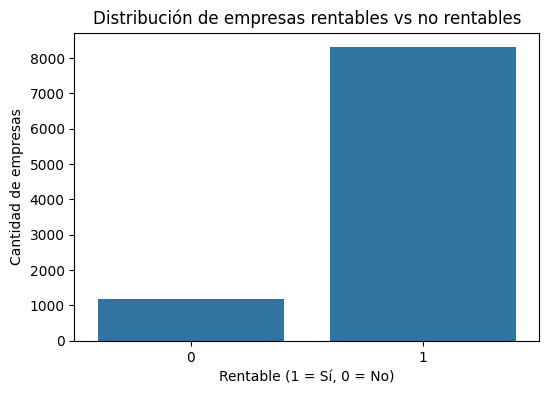

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='RENTABLE')
plt.title('Distribución de empresas rentables vs no rentables')
plt.xlabel('Rentable (1 = Sí, 0 = No)')
plt.ylabel('Cantidad de empresas')
plt.show()

**Gráfico barplot**

Encontramos ahora las empresas rentables por macrosector en donde podemos ver que el de construcción es aquel que tiene la proporción más alta aproximadamente más del 0.9 y el minero la más baja con aproximadamente 0.78, siendo una amplia diferencia entre ambas.

Ahora, si nos fijamos bien en las líneas verticales que muestran el intervalo de confianza, apreciamos que gran parte de los macrosectores suelen tener poca variabiliad, cosa que no sucede con el macrosector minero y agropecuario principalmente debido a que probablemente no hay tantas empresas de estos sectores comparado con los demás.

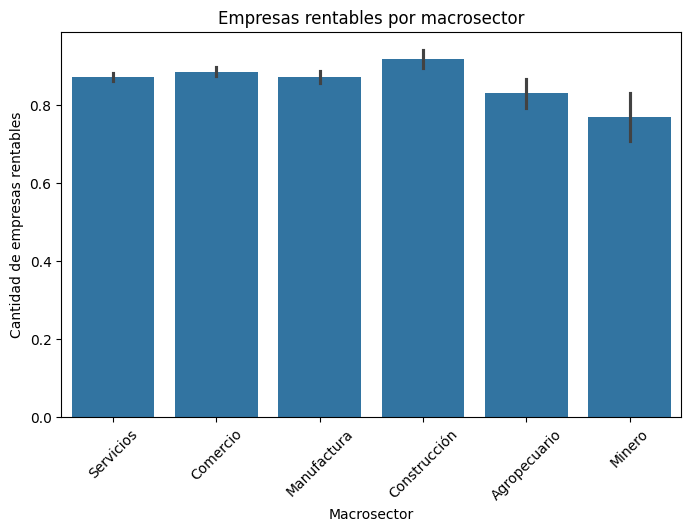

In [22]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='MACROSECTOR', y='RENTABLE', order=df['MACROSECTOR'].value_counts().index)
plt.title('Empresas rentables por macrosector')
plt.xlabel('Macrosector')
plt.ylabel('Cantidad de empresas rentables')
plt.xticks(rotation=45)
plt.show()

**Gráfico barplot por región**

Gran parte de las empresas grandes ubicadas en el país cuentan con un buen rendimiento económico. Sin embargo, hay una gran excepción con el departamento de Vichada, Amazonas y Quindio cuyos resultados reflejan primero una baja rentabilidad en esas regiones y tambien pocas empresas situadas en esos departamentos (especialmente en Vichada y Amazonas).

Por otro lado, podemos reconocer que Bogotá y Antioquia son las regiones más estables si tenemos en cuenta el rendimiento y el intervalo de confianza.

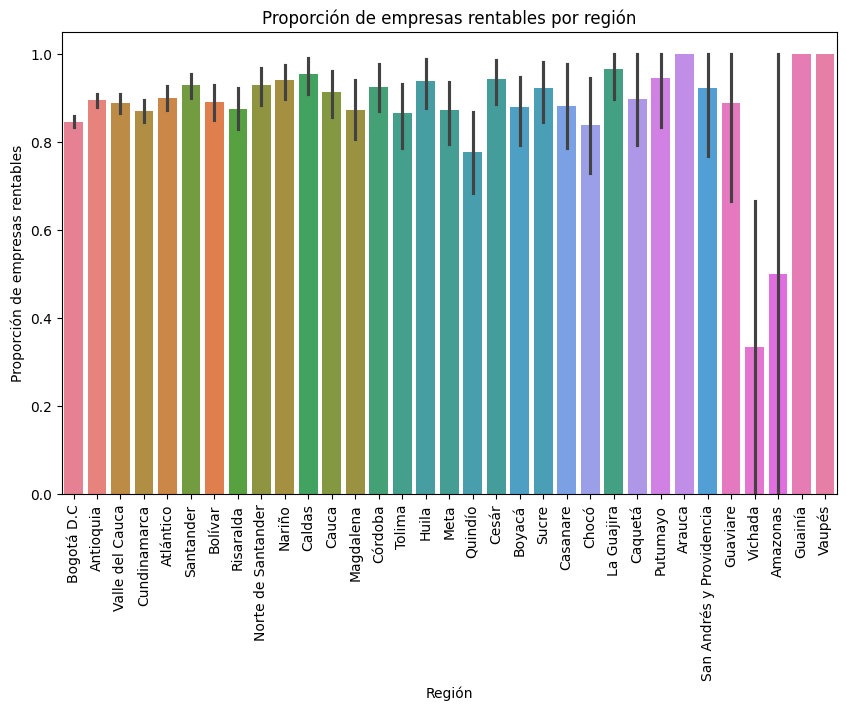

In [23]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Estado/Provincia/Región', y='RENTABLE',
            order=df['Estado/Provincia/Región'].value_counts().index, hue='Estado/Provincia/Región')
plt.title('Proporción de empresas rentables por región')
plt.xlabel('Región')
plt.ylabel('Proporción de empresas rentables')
plt.xticks(rotation=90)
plt.show()

**Gráfico de boxplot**

Se presenta una comparación entre dos variables (apalancamiento y prueba ácida) contra la rentabilidad, esto con el fin de elegir una de estas para que pueda usarse con los modelos.

Lo que podemos decir del resultado de estas gráficas es que ninguna de las dos variables por si sola distingue entre las dos clases, nos podría llevar a que deberíamos tener en cuenta a más variables para ejecutar el modelo.

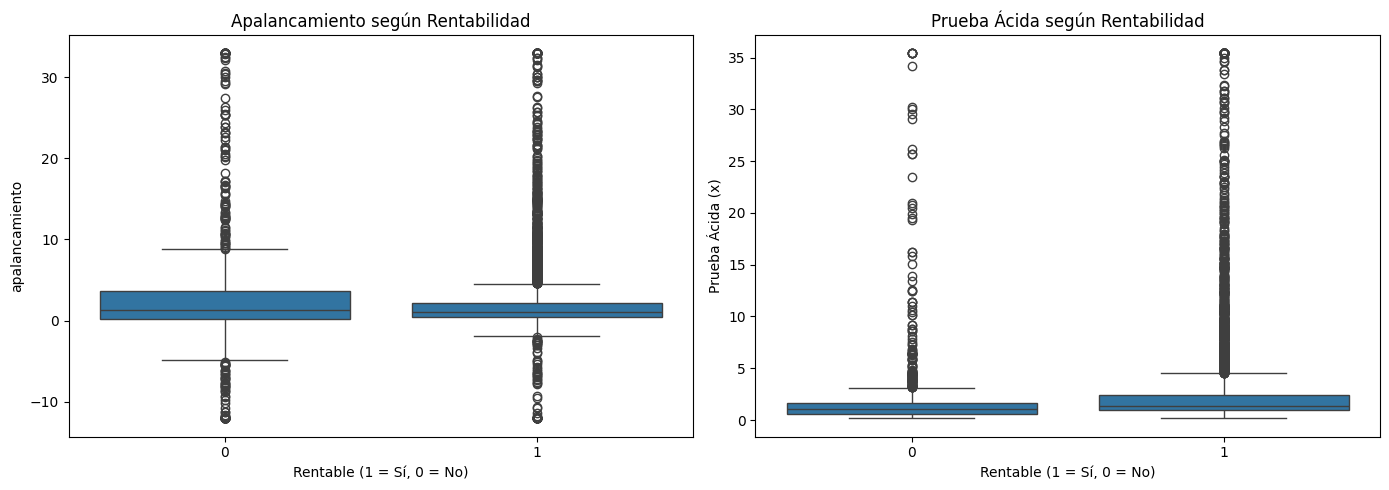

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(data=df, x='RENTABLE', y='apalancamiento', ax=axes[0])
axes[0].set_title('Apalancamiento según Rentabilidad')
axes[0].set_xlabel('Rentable (1 = Sí, 0 = No)')

sns.boxplot(data=df, x='RENTABLE', y='Prueba Ácida (x)', ax=axes[1])
axes[1].set_title('Prueba Ácida según Rentabilidad')
axes[1].set_xlabel('Rentable (1 = Sí, 0 = No)')

plt.tight_layout()
plt.show()

**Gráfico scatterplot:**

En este gráfico de puntos se decidió cruzar las variables del apalancamiento y la prueba ácida con el fin de ver si hay una relación entre ellos y la rentabilidad de forma más clara.

Lo que se puede decir de esto es que no existe un patrón totalmente claro por parte de las empresas no rentables para poder identificarlas.

Por el lado de las que si son rentabes, vemos que hay una fuerte correlación entre el apalancamiento < 0 y la rentabilidad, pero esto no llega a ser totalmente decisivo pues existe ciertas compañías que si se salen de ese patrón y que siguen siendo rentables aún así tengan un apalancamiento negativo.

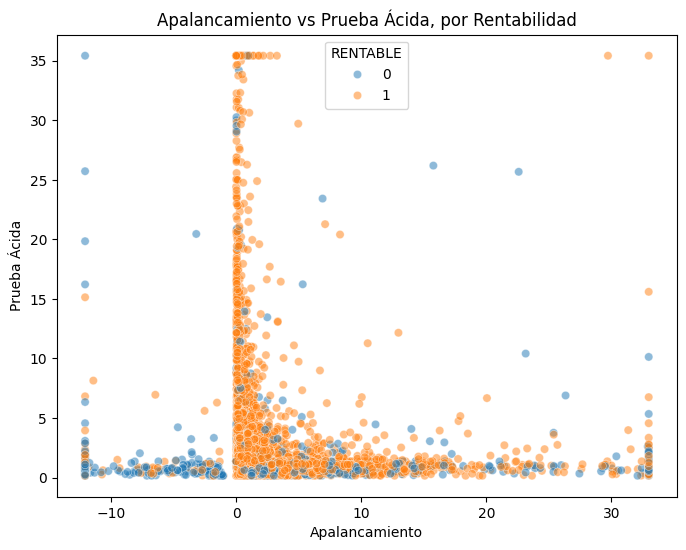

In [25]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='apalancamiento', y='Prueba Ácida (x)',
                 hue='RENTABLE', alpha=0.5)
plt.title('Apalancamiento vs Prueba Ácida, por Rentabilidad')
plt.xlabel('Apalancamiento')
plt.ylabel('Prueba Ácida')
plt.show()

**Gráfico de heatmap**

Se decidió usar tambien un heatmap para este proyecto con la finalidad de encontrar correlaciones entre variables demasiado fuertes entre si y que pueda confundir a modelos como la regresión lineal.

En este caso, se encuentra una fuerte correlación entre pasivos y activos del 0.96, por lo que se decide quitar una de ellas, en este caso pasivos totales.

De esta manera, se puede evitar la repetición de la información.

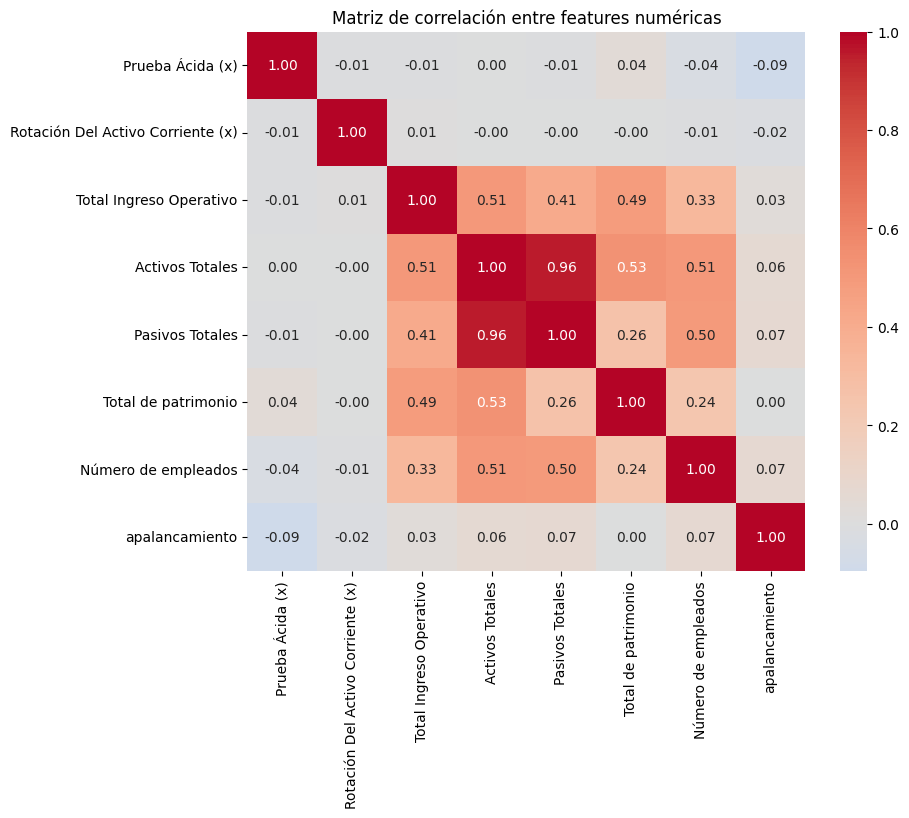

In [26]:
numericas_finales = ['Prueba Ácida (x)', 'Rotación Del Activo Corriente (x)',
                      'Total Ingreso Operativo', 'Activos Totales',
                      'Pasivos Totales', 'Total de patrimonio',
                      'Número de empleados', 'apalancamiento']

plt.figure(figsize=(9,7))
sns.heatmap(df[numericas_finales].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de correlación entre features numéricas')
plt.show()

#**7 Modelado y Evaluación**

Después de haber hecho toda la corrección de outliers, el graficado y la elección de las variables, procedemos al modelado.

En este caso, comenzamos partiendo los datos de entrenamiento y los de test.

Para ello, ponemos todas las variables que queremos usar para el modelo incluyendo las numéricas y categóricas (aquellas serán usadas como la variable independiente contra RENTABLE que es la dependiente).

Luego de ello, indicamos cual será la cantidad de datos para entreno (en este caso será el 80%) y la de test (el 20%)

Y por último, usamos stratify para asegurarnos que la proporción del target que ya sabemos que está desbalanceada sea igual para el entreno así como para el test y de esta manera evitar sesgos.

In [27]:
from sklearn.model_selection import train_test_split

features_numericas = ['Total Ingreso Operativo', 'Activos Totales', 'Total de patrimonio',
                       'Número de empleados', 'apalancamiento', 'Prueba Ácida (x)',
                       'Rotación Del Activo Corriente (x)']
features_categoricas = ['MACROSECTOR', 'Estado/Provincia/Región']

X = df[features_numericas + features_categoricas]
y = df['RENTABLE']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

**Encoding:**

Como para este proyeto usaremos modelos de clasificación, necesitamos encodear las variables categóricas para que puedan ser leídas por el modelo.

Por tal motivo, usaremos One Hot Encoding para lograrlo, en este caso se crearán 39 columnas entre estas dos variables. Este sistema puede que no sea tan eficiente para ser usado en modelos con más datos, pero como este solo tiene 10.000, el tiempo de procesamiento no es demasiado.

In [28]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_cat = encoder.fit_transform(X_train[features_categoricas])
X_test_cat = encoder.transform(X_test[features_categoricas])

nombres_cols_cat = encoder.get_feature_names_out(features_categoricas)
print(nombres_cols_cat)
print(X_train_cat.shape)

['MACROSECTOR_Agropecuario' 'MACROSECTOR_Comercio'
 'MACROSECTOR_Construcción' 'MACROSECTOR_Manufactura' 'MACROSECTOR_Minero'
 'MACROSECTOR_Servicios' 'Estado/Provincia/Región_Amazonas'
 'Estado/Provincia/Región_Antioquia' 'Estado/Provincia/Región_Arauca'
 'Estado/Provincia/Región_Atlántico' 'Estado/Provincia/Región_Bogotá D.C'
 'Estado/Provincia/Región_Bolívar' 'Estado/Provincia/Región_Boyacá'
 'Estado/Provincia/Región_Caldas' 'Estado/Provincia/Región_Caquetá'
 'Estado/Provincia/Región_Casanare' 'Estado/Provincia/Región_Cauca'
 'Estado/Provincia/Región_Cesár' 'Estado/Provincia/Región_Chocó'
 'Estado/Provincia/Región_Cundinamarca' 'Estado/Provincia/Región_Córdoba'
 'Estado/Provincia/Región_Guainía' 'Estado/Provincia/Región_Guaviare'
 'Estado/Provincia/Región_Huila' 'Estado/Provincia/Región_La Guajira'
 'Estado/Provincia/Región_Magdalena' 'Estado/Provincia/Región_Meta'
 'Estado/Provincia/Región_Nariño'
 'Estado/Provincia/Región_Norte de Santander'
 'Estado/Provincia/Región_Putumayo' 'Es

**Escalado:**

Como usaremos la regresión logística, tambien necesitamos que todas las variables se encuentren en la misma escala, por lo que usaremos StandardScaler para hacerlo.

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[features_numericas])
X_test_num = scaler.transform(X_test[features_numericas])

**Unión de features numéricas y categóricas:**

FInalmente, unimos todas las variables para presentarselas a los modelos y nos aseguramos que hayan quedado unidas con .shape

In [30]:
import numpy as np

X_train_final = np.hstack([X_train_num, X_train_cat])
X_test_final = np.hstack([X_test_num, X_test_cat])

print(X_train_final.shape, X_test_final.shape)

(7576, 46) (1895, 46)


**Feature selection:**

De todas las variables que se han preparado, solo se usará una parte de ellas, así que con feature selection se evaluarán cuales son las que más información aporta cada variable para predecir el target teniendo en cuenta que solo tomará las mejores 15.

In [31]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

selector = SelectKBest(score_func=mutual_info_classif, k=15)
X_train_selected = selector.fit_transform(X_train_final, y_train)
X_test_selected = selector.transform(X_test_final)

nombres_todas_cols = list(features_numericas) + list(nombres_cols_cat)
nombres_seleccionadas = np.array(nombres_todas_cols)[selector.get_support()]

nombres_seleccionadas


array(['Total Ingreso Operativo', 'Total de patrimonio', 'apalancamiento',
       'Prueba Ácida (x)', 'MACROSECTOR_Agropecuario',
       'MACROSECTOR_Servicios', 'Estado/Provincia/Región_Antioquia',
       'Estado/Provincia/Región_Bolívar', 'Estado/Provincia/Región_Cesár',
       'Estado/Provincia/Región_Guainía',
       'Estado/Provincia/Región_Guaviare',
       'Estado/Provincia/Región_Nariño',
       'Estado/Provincia/Región_Quindío',
       'Estado/Provincia/Región_Valle del Cauca',
       'Estado/Provincia/Región_Vichada'], dtype='<U48')

**Entrenamiento de los modelos:**

Regresión logística: Usamos balanced como parámetro para que el modelo le de más importancia a los errores sobre la clase minoritaria. Asimismo, usamos un máximo de iteraciones de 1000 para que encuentre la mejor respuesta.

Random forest: Para este modelo tambien usamos el parámetro balanced y usamos un número de estimadores de 100 para que en conjunto tomen la desición final.

Nota: Este modelo no fue explicado a fondo en la clase, pero, yo lo quise traer a colación y usarlo en el proyecto ya que lo había estudiado en la universidad durante mis clases de Datastorytelling con machine learning y sabía que era muy similar al árbol de decisiones y que incluso podía llevar a un mejor resultado.

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train_selected, y_train)

rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
rf.fit(X_train_selected, y_train)

print("Modelos entrenados")

Modelos entrenados


**Métricas de evaluación:**

Le presentamos a los modelos los datos de testeo con la finalidad de predecir el target.

Por último le pedimos un reporte de los resultados de dicho test.

Nota: Nos enfocaremos principalmente en los resultados de "No Rentable", es decir en 0

Regresión logística: Tuvo un accuracy del 60%, sin embargo en la precisión para encontrar las empresas no rentables es muy bajo (apenas del 15%) lo cual hace disminuir el f1-score que da como resultado un 23%, un valor muy bajo.

Random forest: Tuvo un resultado general mejor que el modelo anterior, con un accuracy del 88% y una precisión del 65%. No obstante, el recall disminuyó muchísimo (14%) lo cual indica que no logró identificar gran parte de las empresas no rentables y lo que hizo que el f1-score quedara igual que la regresión (23%)

In [33]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_log = log_reg.predict(X_test_selected)
y_pred_rf = rf.predict(X_test_selected)

print("Regresión Logística")
print()
print(classification_report(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))

print("\nRandom Forest")
print()
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Regresión Logística

              precision    recall  f1-score   support

           0       0.13      0.56      0.21       234
           1       0.89      0.49      0.63      1661

    accuracy                           0.50      1895
   macro avg       0.51      0.52      0.42      1895
weighted avg       0.79      0.50      0.58      1895

[[130 104]
 [846 815]]

Random Forest

              precision    recall  f1-score   support

           0       0.62      0.15      0.24       234
           1       0.89      0.99      0.94      1661

    accuracy                           0.88      1895
   macro avg       0.76      0.57      0.59      1895
weighted avg       0.86      0.88      0.85      1895

[[  35  199]
 [  21 1640]]


**Ajuste de modelos con hiperparámetros**

En el caso de la regresión, se utilizó C para controlar la regularización y se probó en varios niveles para los datos de entreno y de test.

**Resultado:** No cambió en practicamente nada lo cual nos da a entender que el modelo ya llegó a su punto más estable y que las variables de forma individual no pueden predecir con mucha exactitud el target.

In [34]:
for c_valor in [0.01, 0.1, 1, 10]:
    modelo = LogisticRegression(C=c_valor, class_weight='balanced', random_state=42, max_iter=1000)
    modelo.fit(X_train_selected, y_train)
    pred = modelo.predict(X_test_selected)
    print(f"C={c_valor}")
    print(classification_report(y_test, pred, target_names=['No Rentable', 'Rentable']))
    print()

C=0.01
              precision    recall  f1-score   support

 No Rentable       0.14      0.56      0.22       234
    Rentable       0.89      0.50      0.64      1661

    accuracy                           0.51      1895
   macro avg       0.51      0.53      0.43      1895
weighted avg       0.80      0.51      0.59      1895


C=0.1
              precision    recall  f1-score   support

 No Rentable       0.13      0.55      0.21       234
    Rentable       0.89      0.49      0.63      1661

    accuracy                           0.50      1895
   macro avg       0.51      0.52      0.42      1895
weighted avg       0.79      0.50      0.58      1895


C=1
              precision    recall  f1-score   support

 No Rentable       0.13      0.56      0.21       234
    Rentable       0.89      0.49      0.63      1661

    accuracy                           0.50      1895
   macro avg       0.51      0.52      0.42      1895
weighted avg       0.79      0.50      0.58      1895



Para el hiperparámetro de random forest, se usó max depth para controlar que tan profundo llega cada estimador, en este caso también se probó con diferentes valores.

**Resultado:** Aquí si podemos decir que hubo una ligera mejora en el apartado de empresas no rentables, pues pasamos de un recall de apenas 14% a uno del 50% si nos enfocamos en el max depth = 5. Además, el f1-score también subió, de un 23% a un 37% lo cual es una mejora significativa aunque eso implique que el accuracy disminuya un poco (a un 79%).
Este resultado es mucho mejor para el modelo pues es capaz de identificar con más frecuencia a las empresas no rentables (la variable más dificil de identificar).

In [35]:
for profundidad in [3, 5, 10, None]:
    modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=profundidad,
                                         class_weight='balanced', random_state=42)
    modelo_rf.fit(X_train_selected, y_train)
    pred_rf = modelo_rf.predict(X_test_selected)
    print(f"max_depth={profundidad}")
    print(classification_report(y_test, pred_rf, target_names=['No Rentable', 'Rentable']))
    print()

max_depth=3
              precision    recall  f1-score   support

 No Rentable       0.27      0.50      0.35       234
    Rentable       0.92      0.81      0.86      1661

    accuracy                           0.77      1895
   macro avg       0.59      0.66      0.60      1895
weighted avg       0.84      0.77      0.80      1895


max_depth=5
              precision    recall  f1-score   support

 No Rentable       0.30      0.50      0.37       234
    Rentable       0.92      0.83      0.88      1661

    accuracy                           0.79      1895
   macro avg       0.61      0.67      0.62      1895
weighted avg       0.84      0.79      0.81      1895


max_depth=10
              precision    recall  f1-score   support

 No Rentable       0.34      0.38      0.36       234
    Rentable       0.91      0.90      0.90      1661

    accuracy                           0.83      1895
   macro avg       0.63      0.64      0.63      1895
weighted avg       0.84      0.83  

**Matríz de confusión:**

Para que haya una mejor visualización de los datos, aquellos se graficaron en una matriz de confusión en la cual se logra ver con mayor detenimiento las diferencias en resultados de ambos modelos siendo Random forest todavía la mejor opción.

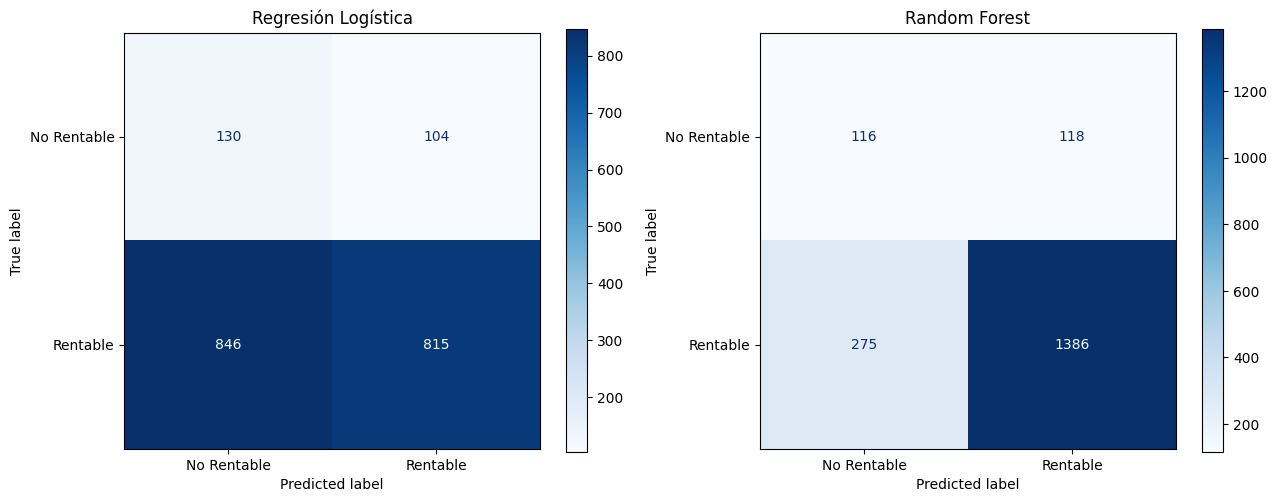

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(13,5))

# Regresión logística
log_reg_final = LogisticRegression(C=1, class_weight='balanced', random_state=42, max_iter=1000)
log_reg_final.fit(X_train_selected, y_train)
pred_log_final = log_reg_final.predict(X_test_selected)

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_log_final, display_labels=['No Rentable', 'Rentable'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Regresión Logística')

# Random forest
rf_final = RandomForestClassifier(n_estimators=100, max_depth=5,
                                    class_weight='balanced', random_state=42)
rf_final.fit(X_train_selected, y_train)
pred_rf_final = rf_final.predict(X_test_selected)

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_rf_final, display_labels=['No Rentable', 'Rentable'],
    cmap='Blues', ax=axes[1]
)
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.show()

#**8. Conclusiones y comunicación:**

El objetivo de este proyecto fue la de identificar diferentes variables financieras, geográficas y sectoriales que permitieran encontrar patrones relacionados a la rentabilidad de cada empresa para lograr predecir a partir de unos pocos datos disponibles, si una compañía es rentable y si en realidad vale la pena invertir en la misma.

Y es que, en el mundo real, a veces no vamos a contar con todos los datos disponibles al momento de invertir, o al menos no con los más importantes (como las ganancias netas, margen operacional, ROA, etc) esto por diferentes razones, puede ser que la empresa no los ha sacado al público todavía o simplemente no son datos que suela compartir.

Es por ello que este estudio se basa en variables más sencillas de encontrar.

**Hallazgos:**

- Los datos muestran que el 87,6% de las 10.000 empresas mas grandes del país son rentables lo cual era algo esperado ya que al ser las compañias de mayor tamaño en el país, era muy probable de que tuvieran un buen margen. Sin embargo, este detalle en especial fue el mayor reto del proyecto pues al existir un desbalance entre las empresas rentables de las que no, esto suponía una mayor dificultad a los modelos para identificar correctamente este 12,4% restante de compañías no rentables.

- Al momento de revisar cada variable por separado (concepto y que función tenían dentro de un informe empresarial) me di cuenta que  variables como el ROA, ROE  y margen operacional están directamente ligadas de forma matemática al target (estas variables se basaban en la Ganancia pérdida neta para poder definirse) lo cual era información que los modelos no debían de conocer ues podrían hacerlo inutil en la vida real.

- Al momento de la exploración visual al no poder usar features realmente determinantes en los modelos como el margen operacional o el ROA debido a que estaban ligadas al target (Cuando el Margen operacional o ROA > 0 = Empresa rentable) se decidió buscar otras variables que pudieran ayudar a predecir esta rentabilidad sin necesidad de que fueran 100% precisas. Es así que llegamos al boxplot y scatterplot del apalacamiento y la prueba ácida en donde vemos que hay una fuerte correlación cuando las empresas que son rentables cuentan en su mayoría con un número superior a 0 en esta variable, logrando así a clasificar a las compañías de forma más sencilla.

**Comparación de modelos:**

Se entrenaron un total de 2 modelos de clasificación (regresión logística y random forest) ambos ajustados con hiperparametros para compensar el desbalance de las clases (Rentable: 87,6% y No Rentable: 12,4%)

De aquí, podemos decir que Random forest obtuvo un mejor desempeño general que la regresión logística, logrando un accuracy del 88% contra un 60% de la regresión logística y lo mas importante de las variables, un F1-Score de 0,36 contra 0,23 de la regresión.

Es evidente que en ambos modelos hubo un bajo rendimiento en identificar de forma correcta a las empresas no rentables, esto debido al mismo desnivel de datos que dificilmente un modelo puede balancear, sin embargo destacamos el uso del random forest por diferentes razones:

- Si un inversionista conservador que prioriza seguridad y busca minimizar los errores, a este se le recomendaría usar random forest entre los dos modelos pues su nivel de accuracy general tiende a ser más alto (0,88 de RF contra 0,59 de regresión)

- Random forest tiende a clasificar de mejor manera a las empresas, especialmente cuando hablamos de los verdaderos positivos, en donde identificó 300 empresas adicionales que la regresión.

- Si bien en el recall, la regresión logística obtuvo en el apartado de empresas no rentables un 0,49 vs un 0,48 del random forest, la precisión disminuyó demasiado (de un 0,29 a tan solo un 0,15), y teniendo en cuenta que solo hubo un punto porcentual de diferencia en el recall entre ambos modelos, esto lo vuelve insignificante y hace del random forest una mejor opción de modelo para este dataset.

**Conclusión final**

Como conclusión final para estos dos modelos, no podemos decir que uno siempre va a ser mejor que otro solo porque en este caso el random forest rindió mejor, sino que esto cambia dependiendo del tema, del dataset y de las variables que se tienen a la mano.
Lo que sucedió en este estudio fue que los datos presentan relaciones no lineales entre las variables y por ello, el modelo de árboles logra clasificar mejor los grupos que un modelo lineal como lo es la regresión logística. Sin embago, esto no es una victoria para el random forest pues ninguno de los modelos alcanzó un recall alto en la clase minoritaría (No Rentable) lo cual confirma que identificar una compañía con alto riesto de rentabilidad con las variables presentes es un desafio.

**Relación con el problema inicial:**

El modelo con todos los ajustes hechos con anterioridad, funciona como una herramienta preliminar que ayuda a los inversionistas y analistas financieros a ahorrar tiempo descartando compañías no rentables y a enfocarse en las que si se generan dinero.
Es importante resaltar que las empresas que fueron consideradas rentables por el modelo, todavía deben ser analizadas por los analístas pues este modelo no elige la mejor compañía de todas para invertir, identifica todas las que son rentables y es tarea de quién revisa los resultados de tomar la decisión final de inversión.

**Próximos pasos:**

- Para mejorar el desempeño del modelo en investigaciones futuras se recomiendaría aplicar otras técnicas de balance que permitan a los modelos ser mas rigorosos al momento de identificar la clase minoritaria de los datos sin perder precisión en la respuesta general.
- Incorporar más variables al dataset que ayuden a los modelos a obtener patrones más claros dentro de los datos.
- Hacer uso de modelos más avanzados y comparar con este proyecto para identificar mejoras o puntos a mejorar.
- Evaluar el comportamiento de las empresas a lo largo de los años para determinar si los patrones cambian a través del tiempo.




## Glosario de Variables Financieras

**Total Ingreso Operativo:** Dinero que la empresa recibe por su actividad principal (ventas de productos o servicios), antes de restar ningún gasto. Indica el tamaño de la operación del negocio.

**Activos Totales:** Todo lo que la empresa posee y tiene valor económico: efectivo, inventario, maquinaria, edificios, cuentas por cobrar, entre otros. Representa el tamaño patrimonial de la empresa.

**Pasivos Totales:** Todo lo que la empresa debe: préstamos bancarios, deudas con proveedores, obligaciones laborales, entre otros. Indica el nivel de compromisos financieros que la empresa debe cumplir.

**Total de Patrimonio:** Lo que realmente le pertenece a los dueños o accionistas de la empresa, después de restar las deudas de los activos (Patrimonio = Activos − Pasivos). Refleja la solidez financiera real del negocio.

**Ganancia (Pérdida) Neta:** Resultado final de la empresa después de restar todos los gastos, intereses de deuda e impuestos a los ingresos. Es la utilidad "de bolsillo" que le queda al negocio, y fue la variable base usada para construir el target RENTABLE.

**Ganancia Operativa (EBIT):** Ganancia que genera el negocio antes de pagar intereses de deuda e impuestos. Mide qué tan rentable es la operación en sí misma, sin el efecto de cómo está financiada la empresa.

**Número de Empleados:** Cantidad de personas que trabajan en la empresa. Sirve como indicador del tamaño operativo, complementario a las cifras financieras.

**Prueba Ácida:** Mide la capacidad de la empresa para pagar sus deudas de corto plazo usando solo sus activos más líquidos (sin contar inventario, que no siempre es fácil de vender rápido). Un valor mayor a 1 generalmente indica buena capacidad de pago inmediato.

**Rotación del Activo Corriente:** Indica cuántas veces al año la empresa "convierte" sus activos de corto plazo (efectivo, inventario, cuentas por cobrar) en ingresos. Un valor más alto sugiere mayor eficiencia operativa.

**ROA (Rendimiento Sobre los Activos):** Porcentaje de ganancia que la empresa genera por cada peso invertido en sus activos totales. Fue excluida del modelo por estar directamente derivada de la Ganancia Neta (fuga de datos).

**ROE (Rendimiento Sobre el Patrimonio):** Porcentaje de ganancia que la empresa genera en relación con el patrimonio de sus dueños. También excluida del modelo por la misma razón que ROA.

**Modelo Z-Score de Altman:** Índice que combina varias razones financieras para estimar la probabilidad de quiebra de una empresa. Se excluyó del modelo por ser una fórmula que ya incorpora varias de las demás variables financieras, generando riesgo de redundancia y fuga de datos.

## Variables creadas durante el proyecto

**MACROSECTOR:** Categoría económica general de la empresa (Comercio, Servicios, Manufactura, Agropecuario, Construcción, Minero), reconstruida a partir del código CIIU de su actividad principal.

**Margen Operacional:** Calculada como EBIT dividido entre Ingresos Operativos. Indica qué porcentaje de cada peso vendido se convierte en ganancia operativa. Finalmente excluida del modelo por depender de EBIT (fuga de datos), aunque se usó en la exploración inicial.

**Apalancamiento:** Calculada como Pasivos Totales dividido entre Patrimonio Total. Mide qué tan endeudada está la empresa en relación con lo que realmente le pertenece a sus dueños: un apalancamiento alto indica que la empresa depende más de deuda que de capital propio para financiarse.

**RENTABLE:** Variable objetivo (target) del modelo. Vale 1 si la Ganancia (Pérdida) Neta de la empresa fue mayor a cero (la empresa fue rentable), y 0 en caso contrario.